In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import reio_mod
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

import scipy.interpolate as interp
from scipy.interpolate import interp1d

from alfred.astrofit import *

T


In [2]:
df

,fX,rHS,tau,Mmin,fesc
sim_n,,,,,
14858,-3.211549,0.8,3.192623,9.60,0.050
12104,-1.716699,0.8,3.186730,9.33,0.275
10630,-3.540608,0.0,3.487252,8.27,0.275
14596,-1.716699,0.0,3.601125,8.53,0.050
18223,-2.884190,0.6,3.697386,8.00,0.500
...,...,...,...,...,...
13311,-2.884190,1.0,3.913385,8.00,0.050
15617,-3.716699,0.2,3.817129,8.53,0.050
17123,-3.053941,0.2,3.589380,8.00,0.500


In [3]:
import alfred.keras_xe_emul
import time

In [6]:
xef

array([1.16183880e+00, 1.16183877e+00, 1.16183873e+00, ...,
       1.08000000e-10, 1.08000000e-10, 1.08000000e-10])

In [10]:
np.asarray(list(params.values()))

array([-2.71669877,  0.2       ,  3.51074603,  9.33      ,  0.275     ])

 First once 0.12244009971618652  sec


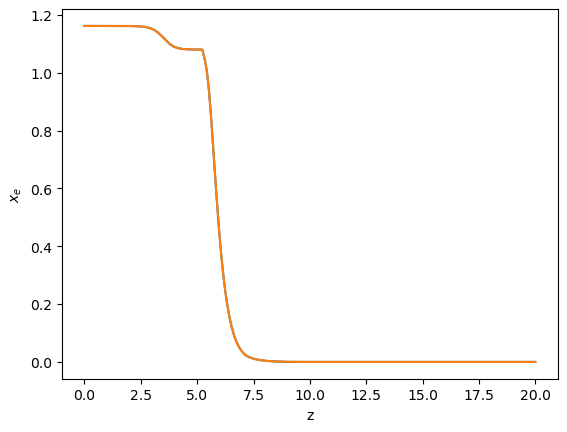

In [4]:
t0 = time.time()

zvect  = np.arange(2000)/100.+1e-6

params = {'fX':-2.71669877, 'rHS':0.2, 'tau': 3.51074603,  'Mmin':9.33, 'fesc': 0.275 }

xef = alfred.keras_xe_emul.xe_emul_dict(zvect, params, plot=True)
xef2 = alfred.keras_xe_emul.xe_emul_array(zvect, np.asarray(list(params.values())), plot=True)

t1=time.time()

print(" First once", t1-t0, " sec" )

9420
{'z': array([15.122 , 14.843 , 14.577 , 14.321 , 14.075 , 13.839 , 13.612 ,
       13.393 , 13.182 , 12.979 , 12.783 , 12.594 , 12.411 , 12.234 ,
       12.063 , 11.898 , 11.737 , 11.581 , 11.43  , 11.284 , 11.142 ,
       11.003 , 10.869 , 10.738 , 10.611 , 10.487 , 10.367 , 10.249 ,
       10.135 , 10.023 ,  9.9147,  9.8085,  9.7049,  9.6037,  9.5048,
        9.4083,  9.3139,  9.2217,  9.1314,  9.0432,  8.9568,  8.8722,
        8.7895,  8.7084,  8.629 ,  8.5512,  8.4749,  8.4002,  8.3269,
        8.255 ,  8.1845,  8.1153,  8.0474,  7.9807,  7.9153,  7.851 ,
        7.7879,  7.7259,  7.6649,  7.6051,  7.5462,  7.4883,  7.4314,
        7.3755,  7.3204,  7.2663,  7.213 ,  7.1606,  7.109 ,  7.0582,
        7.0082,  6.9589,  6.9104,  6.8627,  6.8156,  6.7693,  6.7236,
        6.6786,  6.6342,  6.5905,  6.5474,  6.5049,  6.463 ,  6.4216,
        6.3809,  6.3406,  6.301 ,  6.2618,  6.2232,  6.1851,  6.1475,
        6.1103,  6.0737,  6.0375,  6.0017,  5.9665,  5.9316,  5.8972,
        5

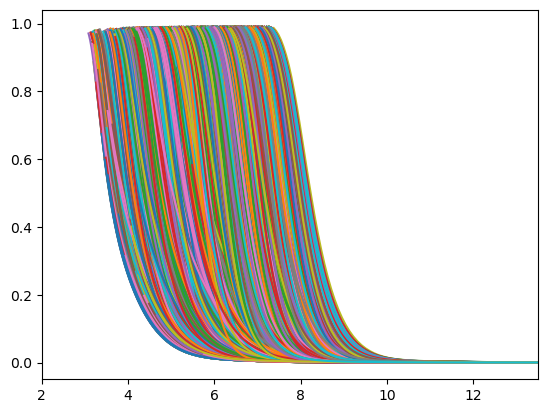

In [6]:
allxe=[]
zfin=[]
xefin=[]
tau =[]
plt.figure()

print(len(xe_histories.keys()))

for key in xe_histories.keys():
    z=np.array(xe_histories[key]["z"])
    xe=np.array(xe_histories[key]["xe"])
    allxe.append(np.vstack((z,xe)))
    zfin.append(z[-3])
    xefin.append(xe[-1])
   # tau.append(reio_mod.xe_to_tau(np.hstack((0,0.99*z[-1],z[::-1])), 1.08*np.hstack((1,1,xe[::-1]+1e-4))))
    plt.plot(z, xe)
plt.xlim(2, 13.5)
zfin  = np.array(zfin)
xefin  = np.array(xefin)

print(xe_histories["14858"])

In [26]:
sims = []

for sn in df.index.to_list():  
    if xe_histories[sn]['xe'].max() >= .97:
        sims.append(sn)

print(f'{len(sims)} available sims reach 97% ionisation')

8234 available sims reach 97% ionisation


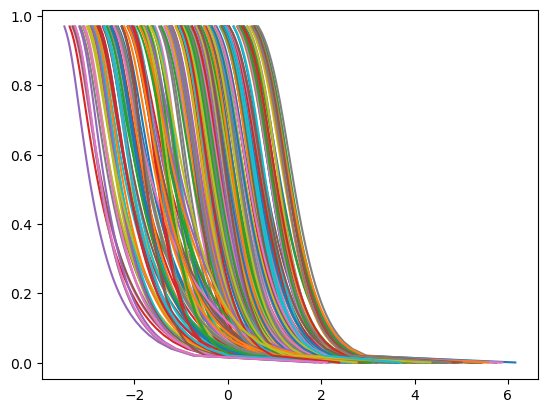

In [27]:
nx=50
#xe_interp = np.arange(nx)/nx+0.01
xe_interp = np.linspace(0.001, 0.97, nx)

#xe_interp = np.logspace(np.log10(0.01), np.log10(0.98), nx)

z_interp = np.zeros((len(sims), nx))
zem =[]
xemax=[]

for i,key in enumerate(sims): # only sims with max xe >= 97%
    #print(key)
    z=np.array(xe_histories[key]["z"])
    xe=np.array(xe_histories[key]["xe"])
    
    xemax.append(np.max(xe))
    zem.append(np.mean(z[xe>0.01]))
    
    z_interp[i,:] = np.interp(np.log10(xe_interp), np.log10(xe), np.log10(z), left=np.log10(10), right=np.log10(4))


zm = np.mean(zem)
zs =  np.std(zem)

#print(xe_interp.shape, zm, zs)

for i in np.arange(250):
    plt.plot((10**z_interp[i,:]-zm)/zs, xe_interp[:])

Index(['fX', 'rHS', 'tau', 'Mmin', 'fesc'], dtype='object')
(9381,)
9420
-3.7166987712964503
(8234, 50)
[np.float64(-3.7166987712964503), np.float64(0.0), np.float64(2.8685856665587655), np.float64(8.0)]
[np.float64(-1.7166987712964503), np.float64(1.0), np.float64(4.021383654057061), np.float64(9.6)]


([<matplotlib.axis.XTick at 0x3180468d0>,
 [Text(0, 0, 'fX'),
  Text(1, 0, 'rHS'),
  Text(2, 0, 'tau'),
  Text(3, 0, 'Mmin'),
  Text(4, 0, 'fesc')])

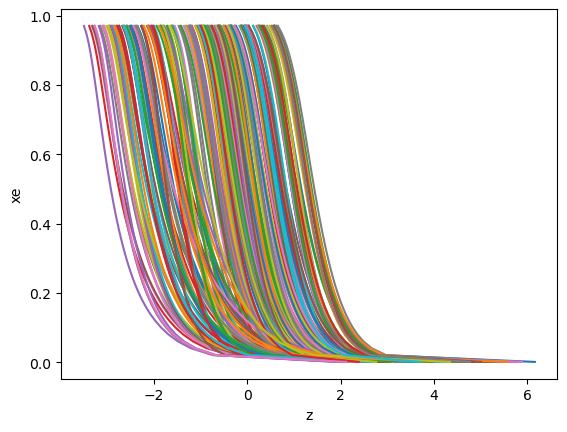

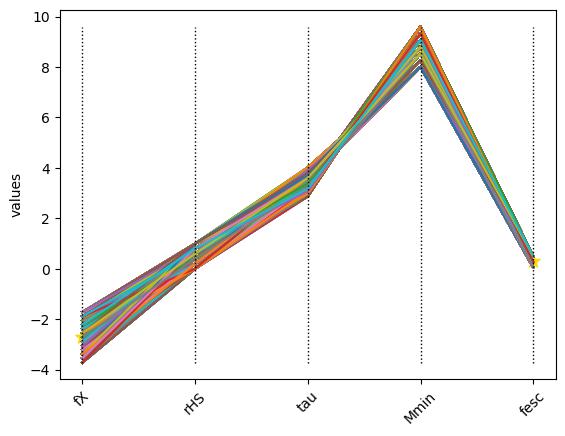

In [36]:
parkey =  df.columns
print(parkey)
print(np.shape(df[parkey[0]]))
print(len(allxe))

allpars = df.loc[sims].to_numpy()
#allpars=[]
allp = allpars
zz_tokeep = z_interp


zz_tokeep = np.array(zz_tokeep)
#print(allp)
allpars  = np.array(allp) #np.log(np.array(allp)+1e-5)
#allpars = np.reshape(np.array(allpars), (np.shape(zz_tokeep))[0], np.size(parkey))
print(allpars.min())
print(zz_tokeep.shape)

print([np.min(allpars[:,i]) for i in np.arange(4)])
print([np.max(allpars[:,i]) for i in np.arange(4)])

for i in np.arange(250):
    plt.plot((10**zz_tokeep[i,:]-zm)/zs, xe_interp[:])
plt.ylabel('xe')
plt.xlabel('z')

plt.figure()
parmeans = np.mean(allpars, axis=0)
parstd = np.std(allpars, axis=0)

for i in np.arange(2500):
    plt.plot((allpars[i,:]))


for i in np.arange(np.size(parkey)):
    #plt.plot(np.arange(np.size(allpars[:,i])), allpars[:,i], 'o')
    plt.vlines(i, np.min(allpars), np.max(allpars), color='k', lw=1,ls=":")  
    plt.scatter(i, parmeans[i], marker='*', s=100, color='gold') 

plt.ylabel('values')
#plt.xlabel(parkey)
plt.xticks(np.arange(np.size(parkey)), labels=parkey, rotation=45)



In [37]:

# Generate sample training data
np.random.seed(0)

XX_train = (allpars-parmeans)/parstd
yy_train = (10**zz_tokeep-zm)/zs #zz_tokeep

# Split data into training and validation sets (e.g., 80% train, 20% validation)

#val_split_index2 = int(0.9 * len(X_train))
#X_test, y_test = X_train[val_split_index2:], y_train[val_split_index2:]
#val_split_index = int(0.8 * len(X_train))
#X_val, y_val = X_train[val_split_index:val_split_index2], y_train[val_split_index:val_split_index2]
#X_train, y_train = X_train[:val_split_index], y_train[:val_split_index]


X_train, X_test, y_train, y_test = train_test_split(XX_train, yy_train, test_size=0.10, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=0)



print(np.shape(X_val), np.shape(y_val   ))
print(np.shape(X_train), np.shape(y_train   ))
print(np.shape(X_test), np.shape(y_test))

#print(X_test, y_test)


(1482, 5) (1482, 50)
(5928, 5) (5928, 50)
(824, 5) (824, 50)


In [38]:

# Define a custom loss function
def custom_loss(y_true, y_pred):
    loss = tf.reduce_mean(tf.losses.binary_crossentropy(y_true, y_pred))
    return loss + 0.01 * tf.reduce_sum(y_pred)  # Adding a small regularization term as an example


layer_norm = tf.keras.layers.Normalization()
layer_norm.adapt(X_train)


# Define the model
model = keras.Sequential([
    layer_norm,
    layers.Dense(nx, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='relu'),
    #layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='linear')#'softmax' 'sigmoid'
])

# Compile the model with the custom loss
#model.compile(optimizer='adam', loss=custom_loss, metrics=['accuracy'])
#loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

#model.compile(optimizer='adam',loss='mse', metrics=['accuracy'])
model.compile(optimizer='adam',loss='mse', metrics=[tf.keras.metrics.MeanSquaredError()])
# Train the model with validation data

history = model.fit(X_train, y_train, epochs=600, batch_size=35, validation_data=(X_val, y_val))



Epoch 1/600


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - loss: 0.9671 - mean_squared_error: 0.9671 - val_loss: 0.0217 - val_mean_squared_error: 0.0217
Epoch 2/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0106 - val_mean_squared_error: 0.0106
Epoch 3/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0064 - val_mean_squared_error: 0.0064
Epoch 4/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0044 - val_mean_squared_error: 0.0044
Epoch 5/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 6/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 0.0028 - mean_squared_error: 0.0028 - val_loss: 0.0025 - val_mean_squared_error: 0.0025
Epoch 7/600
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 0.0021 - mean_squared_error: 0.0021 - val_l

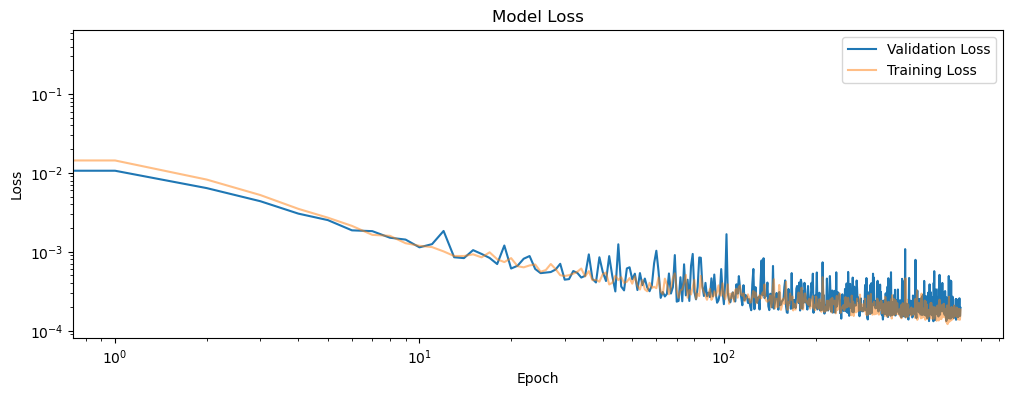

In [39]:
# Plot training & validation loss values
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
#plt.loglog(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.loglog(history.history['loss'], label='Training Loss', alpha=0.5)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(824, 50) (824, 5)


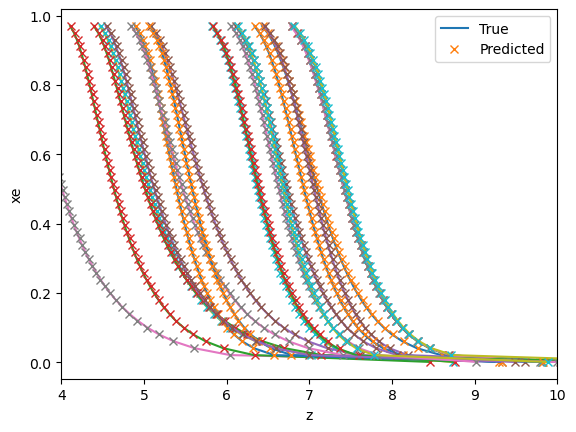

In [40]:
Y_test = history.model.predict(X_test)


print(np.shape(Y_test),np.shape(X_test))
plt.figure()
deb=35
for i in np.arange(20)+deb:
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    if i ==deb :
        plt.plot(y_test[i]*zs+zm, xe_interp, label='True')
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x", label='Predicted')
    else:
        plt.plot(y_test[i]*zs+zm, xe_interp)
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x")
    #print(Y_test[i,10])
    plt.legend()
    plt.ylabel('xe')
    plt.xlabel('z')
    plt.xlim(4,10)
    

In [41]:
print(np.shape(y_test), np.shape(Y_test))


(824, 50) (824, 50)


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_28700/1195368032.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


0.03057951347175383


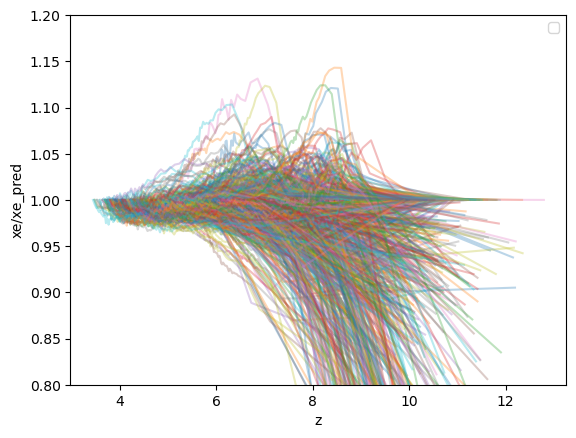

In [42]:
deb=35
trucratio = np.zeros((np.shape(y_test)[0], nx))

for i in np.arange(np.shape(y_test)[0]):
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    #plt.plot(xe_interp,y_test[i]/Y_test[i], alpha=0.5)
    
    #plt.plot(y_test[i]*zs+zm, xe_interp)
    #plt.plot(y_test[i]*zs+zm, np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], "x")
    plt.plot(y_test[i]*zs+zm, xe_interp/np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], alpha=0.3)
    trucratio[i,:]  = (xe_interp/np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1])
    plt.legend()
    plt.ylabel('xe/xe_pred')
    plt.xlabel('z')
    #plt.xlim(0,1)
    plt.ylim(0.8,1.2)

print(np.std(trucratio))
    

In [ ]:
# tau_true = np.zeros((np.shape(y_test)[0]))
# tau_pred = np.zeros((np.shape(y_test)[0]))

# truc = np.zeros((np.shape(y_test)[0], nx))

# for i in np.arange(np.shape(y_test)[0]):
#     #plt.plot(z_interp, y_test[i], label='True')
#     #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
#     #plt.plot(xe_interp,y_test[i]/Y_test[i], alpha=0.5)
    
#     #plt.plot(y_test[i]*zs+zm, xe_interp)
#     #plt.plot(y_test[i]*zs+zm, np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], "x")
#     plt.plot(y_test[i]*zs+zm, (xe_interp-np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1]), alpha=0.3)

#     truc[i,:]  = (xe_interp-np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1])
#     tau_true[i]= reio_mod.xe_to_tau(y_test[i,::-1]*zs+zm, xe_interp[::-1])
#     tau_pred[i] = reio_mod.xe_to_tau(y_test[i,::-1]*zs+zm, (np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])))
#     plt.legend()
#     plt.ylabel('xe-xe_pred')
#     plt.xlabel('z')
#     #plt.xlim(0,1)
#     plt.ylim(-0.1,0.1)


In [ ]:

plt.figure()
plt.plot(xe_interp[::-1], np.std(truc,axis=0),"k" ,alpha=1, label="+1 std difference")
plt.plot(xe_interp[::-1], -np.std(truc,axis=0),"k", alpha=1, label="-1 std difference")
plt.plot(xe_interp[::-1], np.std(trucratio,axis=0),"r" ,alpha=1, label="+1 std ratio")
plt.plot(xe_interp[::-1], -np.std(trucratio,axis=0),"r", alpha=1, label="-1 std ratio")

plt.xticks(np.arange(6)/5, labels=np.round(1.0-np.arange(6)/5., decimals=1), rotation=0)
plt.ylim(-0.05,0.05)
plt.legend()
plt.ylabel('xe vs xe_pred')
plt.xlabel('xe')
 

In [ ]:
plt.scatter(tau_true,tau_pred) 
plt.xlabel('tau_true')
plt.ylabel('tau_pred')

In [ ]:
plt.plot(tau_true/tau_pred) 
plt.xlabel("sim N")
plt.ylabel('tau_true/tau_pred')
print(np.std(tau_true/tau_pred))

In [ ]:
np.__version__


In [43]:
model.save("model.keras")
parmeansstd = {'fX':{"mean":parmeans[0], "std":parstd[0]}, 'rHS':{"mean":parmeans[1], "std":parstd[1]}, 'tau':{"mean":parmeans[2],
                "std":parstd[2]}, 'Mmin':{"mean":parmeans[3], "std":parstd[3]}, 'fesc':{"mean":parmeans[4], "std":parstd[4]}}

np.save("pmean_pstd_zm_zs_xev.npy", {"parmeansstd":parmeansstd ,"zm":zm, "zs":zs, "xe_int":xe_interp})


In [ ]:
Y_test / model.predict(X_test)

In [ ]:
zm / data.item()["zm"], zs / data.item()["zs"]

In [ ]:
Y_test = history.model.predict(X_test)


print(np.shape(Y_test),np.shape(X_test))
plt.figure()
deb=35
for i in np.arange(20)+deb:
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    if i ==deb :
        plt.plot(y_test[i]*zs+zm, xe_interp, label='True')
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x", label='Predicted')

In [ ]:
df.columns.to_numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


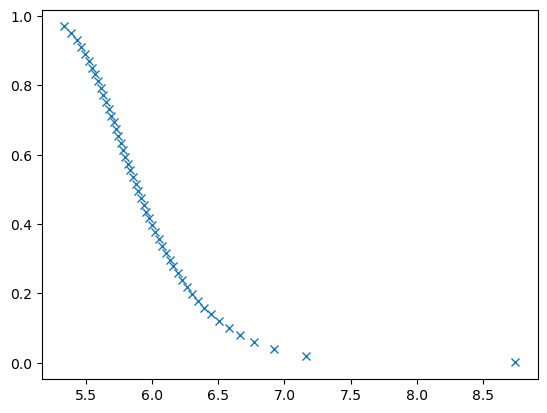

In [45]:
model = keras.models.load_model(f'/Users/emcbride/alfred/model.keras')
data = np.load("pmean_pstd_zm_zs_xev.npy", allow_pickle=True)


z_fin  = np.arange(10000)/500.+1e-1

params = {'fX':-2.71669877 ,  'rHS':0.2        , 'tau': 3.51074603  , 'Mmin':9.33       , 'fesc': 0.275 }
#params = {'fX':1.02994486, 'rHS':-0.27050967, 'tau':-1.4320606, 'Mmin':0.58003171, 'fesc':1.0414419}



parmeansstd = data.item()["parmeansstd"]
zm = data.item()["zm"]    
zs = data.item()["zs"]
xe_interp = data.item()["xe_int"]


X0_values = np.array([(params[key]-parmeansstd[key]["mean"])/parmeansstd[key]["std"] for key in params.keys()])
Yval = model.predict(X0_values[None,:])

plt.plot(Yval[0].T*zs+zm, xe_interp, "x")


In [ ]:

zval = (Yval.T * zs + zm).flatten()[::-1]
x_vals = np.hstack(([1e-1,0.98*zval[0]],zval.flatten()))
x_vals = np.hstack((x_vals,[1.02*zval[-1]]))
                    
y_vals = np.hstack(([1,1],xe_interp.flatten()[::-1]))
y_vals = np.hstack((y_vals,[0.5*y_vals[-1]]))

print(x_vals,y_vals)

xe_fin = 1.08* 10**(np.interp(np.log10(z_fin), np.log10(x_vals), np.log10(y_vals), left=np.log10(1), right=-10))


plt.plot(z_fin, xe_fin)
plt.plot(Yval.T*zs+zm, 1.08*xe_interp, "x")

print(np.min(xe_fin), np.max(xe_fin))

In [ ]:
parkey

In [ ]:
print(allpars[1000,:])
